# F1 2026 Race Data Analytics

This project analyzes Formula 1 race data using the FastF1 API.

Technologies Used:
- Python
- NumPy
- Pandas
- Matplotlib
- Seaborn
- FastF1 API

In [32]:
!pip install fastf1 pandas numpy matplotlib seaborn

## Import Libraries

In [3]:
import fastf1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from fastf1 import plotting
plotting.setup_mpl()

# Create the cache directory if it doesn't exist
os.makedirs('cache', exist_ok=True)
fastf1.Cache.enable_cache('cache')

## Load Race Data

In [6]:
session = fastf1.get_session(2026, "Australia", "R")

session.load()

core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.1]
INFO:fastf1.fastf1.core:Loading data for Australian Grand Prix - Race [v3.8.1]
req            INFO 	No cached data found for session_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
INFO:fastf1.api:Fetching session info data...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
INFO:fastf1.api:Fetching driver list...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
INFO:fastf1.fastf1.req:No cached data found for session_st

##Here we USE

R for Race and for other session Q = Qualifying

FP1 FP2 FP3 = Practice

S = Sprint

In [7]:
laps = session.laps
laps.head()

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,Sector3Time,Sector1SessionTime,Sector2SessionTime,Sector3SessionTime,SpeedI1,SpeedI2,SpeedFL,SpeedST,IsPersonalBest,Compound,TyreLife,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
0,0 days 01:03:56.437000,NOR,1,0 days 00:01:36.458000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:18.163000,0 days 00:00:38.796000,NaT,0 days 01:03:17.998000,0 days 01:03:56.692000,229.0,291.0,304.0,217.0,False,MEDIUM,1.0,True,McLaren,0 days 01:02:19.743000,2026-03-08 04:03:26.366,1,6.0,False,,False,False
1,0 days 01:05:23.781000,NOR,1,0 days 00:01:27.344000,2.0,1.0,NaT,NaT,0 days 00:00:31.074000,0 days 00:00:18.116000,0 days 00:00:38.154000,0 days 01:04:27.511000,0 days 01:04:45.627000,0 days 01:05:23.781000,243.0,287.0,303.0,260.0,True,MEDIUM,2.0,True,McLaren,0 days 01:03:56.437000,2026-03-08 04:05:03.060,1,6.0,False,,False,True
2,0 days 01:06:50.644000,NOR,1,0 days 00:01:26.863000,3.0,1.0,NaT,NaT,0 days 00:00:30.541000,0 days 00:00:18.252000,0 days 00:00:38.070000,0 days 01:05:54.322000,0 days 01:06:12.574000,0 days 01:06:50.644000,245.0,311.0,286.0,273.0,True,MEDIUM,3.0,True,McLaren,0 days 01:05:23.781000,2026-03-08 04:06:30.404,1,7.0,False,,False,True
3,0 days 01:08:16.501000,NOR,1,0 days 00:01:25.857000,4.0,1.0,NaT,NaT,0 days 00:00:30.190000,0 days 00:00:18.193000,0 days 00:00:37.474000,0 days 01:07:20.834000,0 days 01:07:39.027000,0 days 01:08:16.501000,249.0,304.0,283.0,276.0,True,MEDIUM,4.0,True,McLaren,0 days 01:06:50.644000,2026-03-08 04:07:57.267,1,7.0,False,,False,True
4,0 days 01:09:42.074000,NOR,1,0 days 00:01:25.573000,5.0,1.0,NaT,NaT,0 days 00:00:29.930000,0 days 00:00:17.868000,0 days 00:00:37.775000,0 days 01:08:46.431000,0 days 01:09:04.299000,0 days 01:09:42.074000,260.0,297.0,280.0,276.0,True,MEDIUM,5.0,True,McLaren,0 days 01:08:16.501000,2026-03-08 04:09:23.124,1,7.0,False,,False,True


In [9]:
laps.columns

Index(['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint',
       'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time',
       'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime',
       'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest',
       'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime',
       'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason',
       'FastF1Generated', 'IsAccurate'],
      dtype='object')

## Exploratory Data Analysis

In this section we explore the dataset to understand
the drivers participating in the race and the number of laps completed.

In [35]:
##check drivers
laps["Driver"].unique()

array(['NOR', 'GAS', 'PER', 'ANT', 'ALO', 'LEC', 'STR', 'ALB', 'VER',
       'LAW', 'OCO', 'LIN', 'COL', 'HAM', 'BOR', 'SAI', 'HAD', 'RUS',
       'BOT', 'BEA'], dtype=object)

In [37]:
##count laps per driver
laps["Driver"].value_counts()

,count
Driver,
NOR,57
ANT,57
VER,57
LEC,57
RUS,57
HAM,57
BEA,56
GAS,56
OCO,56


In [38]:
##Check dataset columns
laps.columns

Index(['Driver', 'LapNumber', 'LapTime', 'Compound', 'Sector1Time',
       'Sector2Time', 'Sector3Time', 'SpeedST', 'LapTime_sec'],
      dtype='object')

##Now We Will Clean the Data

The dataset contains lap timing and telementry info. We select relevant columns and remove missing values

In [11]:
laps = laps[[
    "Driver",
    "LapNumber",
    "LapTime",
    "Compound",
    "Sector1Time",
    "Sector2Time",
    "Sector3Time",
    "SpeedST"
]]

laps = laps.dropna()
laps["LapTime_sec"] = laps["LapTime"].dt.total_seconds()

laps.head()

,Driver,LapNumber,LapTime,Compound,Sector1Time,Sector2Time,Sector3Time,SpeedST,LapTime_sec
1,NOR,2.0,0 days 00:01:27.344000,MEDIUM,0 days 00:00:31.074000,0 days 00:00:18.116000,0 days 00:00:38.154000,260.0,87.344
2,NOR,3.0,0 days 00:01:26.863000,MEDIUM,0 days 00:00:30.541000,0 days 00:00:18.252000,0 days 00:00:38.070000,273.0,86.863
3,NOR,4.0,0 days 00:01:25.857000,MEDIUM,0 days 00:00:30.190000,0 days 00:00:18.193000,0 days 00:00:37.474000,276.0,85.857
4,NOR,5.0,0 days 00:01:25.573000,MEDIUM,0 days 00:00:29.930000,0 days 00:00:17.868000,0 days 00:00:37.775000,276.0,85.573
5,NOR,6.0,0 days 00:01:25.036000,MEDIUM,0 days 00:00:30.025000,0 days 00:00:17.829000,0 days 00:00:37.182000,273.0,85.036


In [39]:
##if we want to see hamilton laps
laps[laps["Driver"] == "HAM"].head()

,Driver,LapNumber,LapTime,Compound,Sector1Time,Sector2Time,Sector3Time,SpeedST,LapTime_sec
695,HAM,2.0,0 days 00:01:24.626000,MEDIUM,0 days 00:00:29.988000,0 days 00:00:18.115000,0 days 00:00:36.523000,282.0,84.626
696,HAM,3.0,0 days 00:01:24.874000,MEDIUM,0 days 00:00:30.233000,0 days 00:00:18.076000,0 days 00:00:36.565000,271.0,84.874
697,HAM,4.0,0 days 00:01:25.066000,MEDIUM,0 days 00:00:30.332000,0 days 00:00:18.021000,0 days 00:00:36.713000,286.0,85.066
698,HAM,5.0,0 days 00:01:24.502000,MEDIUM,0 days 00:00:29.967000,0 days 00:00:18.029000,0 days 00:00:36.506000,285.0,84.502
699,HAM,6.0,0 days 00:01:24.703000,MEDIUM,0 days 00:00:29.970000,0 days 00:00:18.016000,0 days 00:00:36.717000,290.0,84.703


In [44]:
##if we want to see the fastest lap of lewis Hamilton
session.laps.pick_drivers("HAM").pick_fastest()

,748
Time,0 days 02:21:35.071000
Driver,HAM
DriverNumber,44
LapTime,0 days 00:01:22.423000
LapNumber,55.0
Stint,2.0
PitOutTime,NaT
PitInTime,NaT
Sector1Time,0 days 00:00:29.094000
Sector2Time,0 days 00:00:17.613000


##Fastest Lap Analysis

Here we Calculate the fastest lap time for each driver to compare their performance in the race

In [13]:
fastest_laps = laps.groupby("Driver")["LapTime_sec"].min().reset_index()

fastest_laps = fastest_laps.sort_values("LapTime_sec")

fastest_laps

,Driver,LapTime_sec
19,VER,82.091
13,NOR,82.358
2,ANT,82.417
9,HAM,82.423
11,LEC,82.579
16,RUS,82.670
6,COL,82.926
4,BOR,83.257
17,SAI,83.590
10,LAW,83.783


Visualization

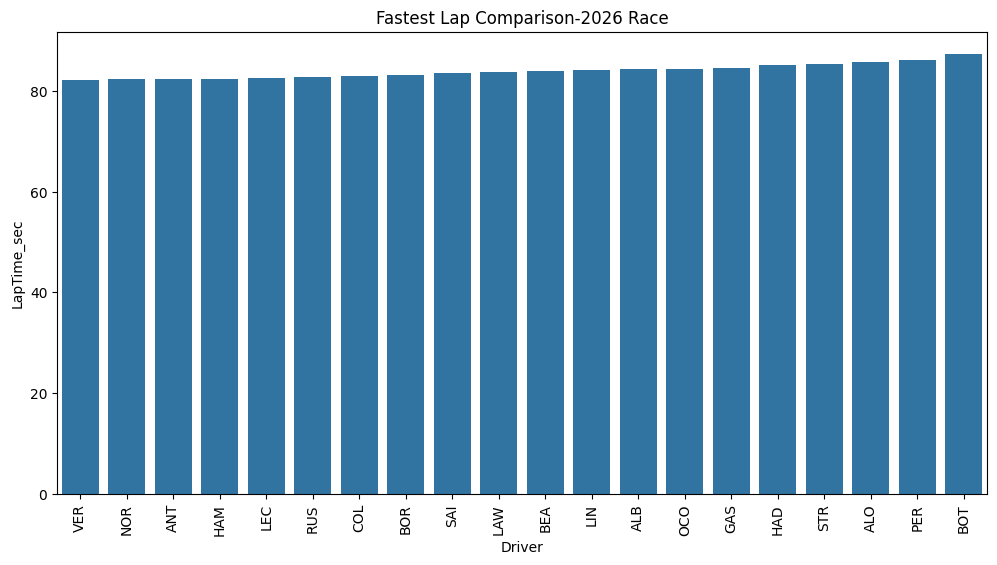

In [15]:
plt.figure(figsize=(12,6))

sns.barplot (
    data = fastest_laps,
    x="Driver",
    y="LapTime_sec"
)

plt.title("Fastest Lap Comparison-2026 Race")

plt.xticks(rotation=90)

plt.show()

##Driver Consistency Analysis
Consistency is measured using the standard deviation of lap times. Lower values indicate more consistent performance.

In [18]:
consistency = laps.groupby("Driver")["LapTime_sec"].std().reset_index()

consistency = consistency.sort_values("LapTime_sec")

consistency

,Driver,LapTime_sec
8,HAD,0.263337
5,BOT,5.141575
14,OCO,7.239387
7,GAS,7.292630
12,LIN,7.428105
11,LEC,7.466210
3,BEA,7.499536
9,HAM,7.622691
15,PER,7.756702
4,BOR,7.964280


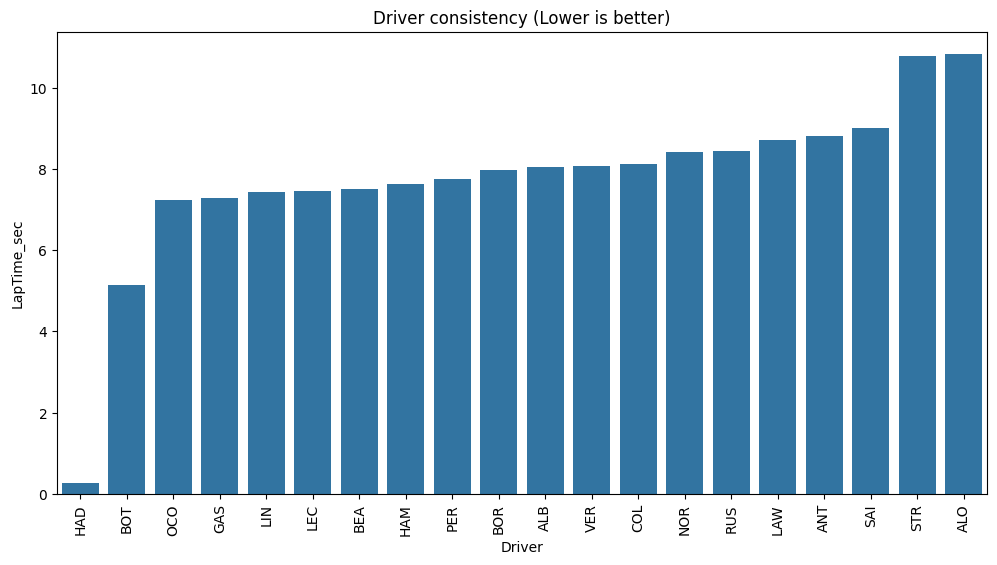

In [19]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=consistency,
    x="Driver",
    y="LapTime_sec"
)
plt.title("Driver consistency (Lower is better)")
plt.xticks(rotation=90)
plt.show()

##TYRE STRATEGY
This visualization shows how lap times change depending on
the tyre compound used during the race.

In [45]:
ham_laps = laps[laps["Driver"] == "VER"]

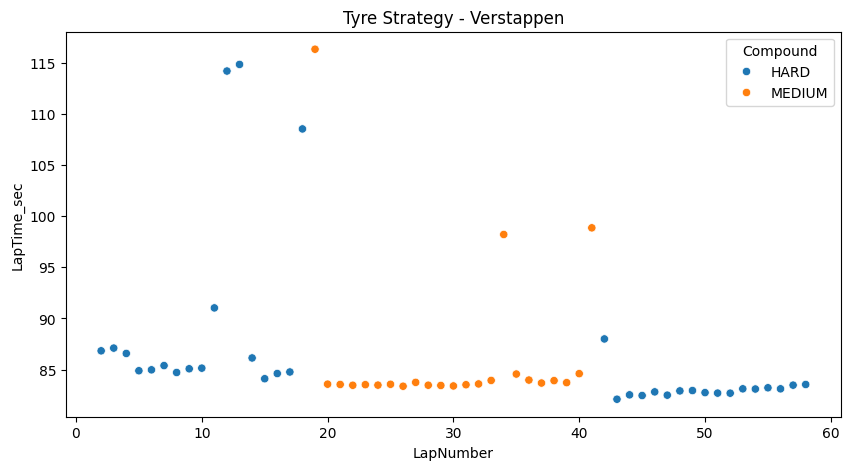

In [47]:
plt.figure(figsize=(10, 5))

sns.scatterplot(
    data=ham_laps,
    x="LapNumber",
    y="LapTime_sec",
    hue="Compound"
)
plt.title("Tyre Strategy - Verstappen")
plt.show()

##TELEMETRY SPEED
We compare speed telemetry between drivers to analyze
performance differences across the track

In [48]:
ver_lap = session.laps.pick_drivers("VER").pick_fastest()
ham_lap = session.laps.pick_drivers("HAM").pick_fastest()

ver_tel = ver_lap.get_car_data().add_distance()
ham_tel = ham_lap.get_car_data().add_distance()


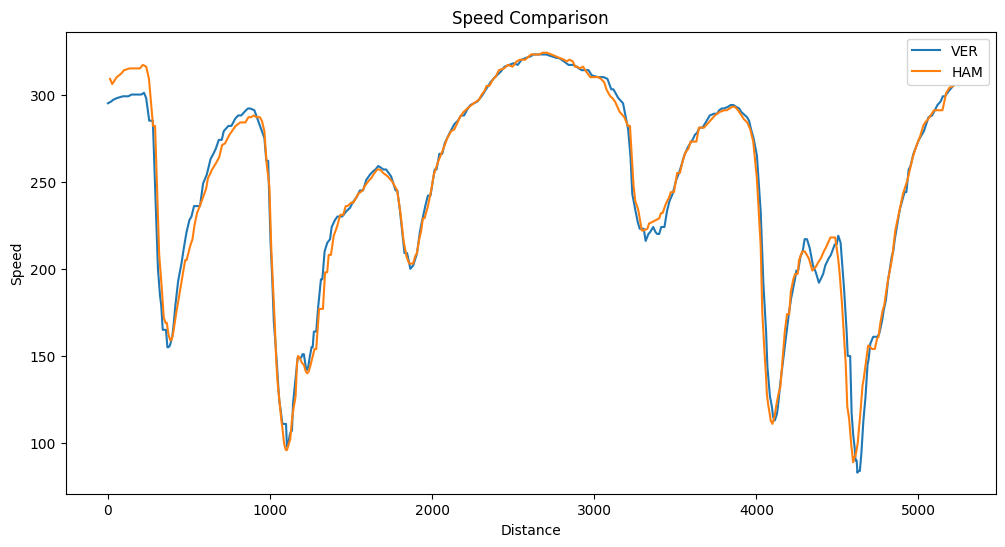

In [28]:
plt.figure(figsize=(12, 6))

plt.plot(ver_tel["Distance"], ver_tel["Speed"], label="VER")
plt.plot(ham_tel["Distance"], ham_tel["Speed"], label="HAM")

plt.title("Speed Comparison")
plt.xlabel("Distance")
plt.ylabel("Speed")

plt.legend()
plt.show()

AVERAGE RACE PACE

In [29]:
race_pace = laps.groupby("Driver")["LapTime_sec"].mean().reset_index()

race_pace = race_pace.sort_values("LapTime_sec")

race_pace

,Driver,LapTime_sec
8,HAD,85.497667
2,ANT,85.838754
16,RUS,85.861526
9,HAM,86.099719
11,LEC,86.147211
19,VER,86.668158
13,NOR,86.703228
3,BEA,87.350518
4,BOR,87.514661
12,LIN,87.545286


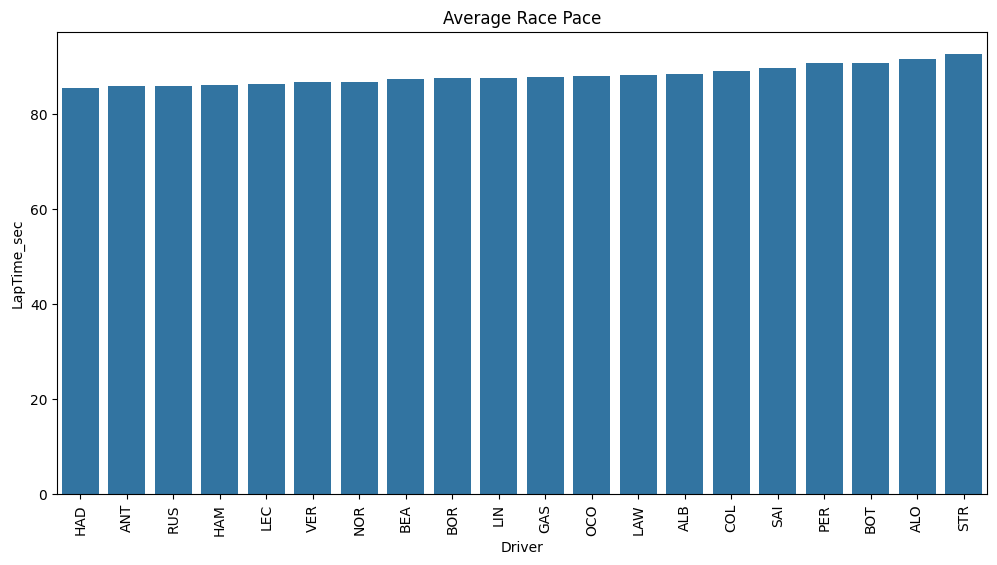

In [30]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data=race_pace,
    x="Driver",
    y="LapTime_sec"
)

plt.title("Average Race Pace")
plt.xticks(rotation= 90)
plt.show()

Export Data

In [31]:
laps.to_csv("f1_2026_race-data.csv", index=False)

## Conclusion

In this project we analyzed Formula 1 race data using the FastF1 API.

Key insights:
- Compared fastest lap times between drivers
- Measured driver consistency using lap time standard deviation
- Explored tyre strategies during the race
- Compared telemetry speed between drivers

This analysis demonstrates how Python and data science tools can be used to analyze real-world motorsport data.